<a href="https://colab.research.google.com/github/rakshit-karlupia/Diwali-sales-data/blob/main/Used_Bike_Prices_Professional_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
sns.set_theme(style="whitegrid")


In [4]:
df = pd.read_csv("/content/bikes.csv")

print("Shape:", df.shape)
display(df.head())


Shape: (7857, 8)


,model_name,model_year,kms_driven,owner,location,mileage,power,price
0,Bajaj Avenger Cruise 220 2017,2017,17000 Km,first owner,hyderabad,\n\n 35 kmpl,19 bhp,63500
1,Royal Enfield Classic 350cc 2016,2016,50000 Km,first owner,hyderabad,\n\n 35 kmpl,19.80 bhp,115000
2,Hyosung GT250R 2012,2012,14795 Km,first owner,hyderabad,\n\n 30 kmpl,28 bhp,300000
3,Bajaj Dominar 400 ABS 2017,2017,Mileage 28 Kms,first owner,pondicherry,\n\n 28 Kms,34.50 bhp,100000
4,Jawa Perak 330cc 2020,2020,2000 Km,first owner,bangalore,\n\n,30 bhp,197500


In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

print("\nRandom sample:")
display(df.sample(5, random_state=42))

print("\nInfo:")
df.info()

print("\nDescriptive statistics:")
display(df.describe(include="all").T)

print("\nUnique values:")
display(df.nunique().sort_values(ascending=False))


Rows: 7857
Columns: 8

Column names:
['model_name', 'model_year', 'kms_driven', 'owner', 'location', 'mileage', 'power', 'price']

Data types:


,0
model_name,object
model_year,int64
kms_driven,object
owner,object
location,object
mileage,object
power,object
price,int64



First 5 rows:


,model_name,model_year,kms_driven,owner,location,mileage,power,price
0,Bajaj Avenger Cruise 220 2017,2017,17000 Km,first owner,hyderabad,\n\n 35 kmpl,19 bhp,63500
1,Royal Enfield Classic 350cc 2016,2016,50000 Km,first owner,hyderabad,\n\n 35 kmpl,19.80 bhp,115000
2,Hyosung GT250R 2012,2012,14795 Km,first owner,hyderabad,\n\n 30 kmpl,28 bhp,300000
3,Bajaj Dominar 400 ABS 2017,2017,Mileage 28 Kms,first owner,pondicherry,\n\n 28 Kms,34.50 bhp,100000
4,Jawa Perak 330cc 2020,2020,2000 Km,first owner,bangalore,\n\n,30 bhp,197500



Last 5 rows:


...

,model_name,model_year,kms_driven,owner,location,mileage,power,price
3703,Royal Enfield Thunderbird X 350cc ABS 2019,2019,10500 Km,first owner,delhi,\n\n,19.80 bhp,160000
1405,Bajaj Pulsar 180cc 2010,2010,25000 Km,first owner,bangalore,\n\n 65 kmpl,15 bhp,22000
994,Bajaj Avenger 180cc 2006,2006,57500 Km,first owner,bangalore,\n\n 40 kmpl,19 bhp,36000
2024,Yamaha YZF-R15 V3 150CC ABS 2019,2019,7000 Km,first owner,sikar,\n\n,18.70 bhp,123100
5617,Suzuki Gixxer 150cc SP Rear Disc 2018,2018,5300 Km,first owner,indore,\n\n 63kmpl,14 bhp,78000



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7857 entries, 0 to 7856
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   model_name  7857 non-null   object
 1   model_year  7857 non-null   int64 
 2   kms_driven  7857 non-null   object
 3   owner       7857 non-null   object
 4   location    7838 non-null   object
 5   mileage     7846 non-null   object
 6   power       7826 non-null   object
 7   price       7857 non-null   int64 
dtypes: int64(2), object(6)
memory usage: 491.2+ KB

Descriptive statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
model_name,7857,1724,Royal Enfield Classic 350cc 2017,78,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model_year,7857.0,NaN,NaN,NaN,2015.367698,4.001443,1950.0,2014.0,2016.0,2018.0,2021.0
kms_driven,7857,1801,Mileage 65 Kmpl,436,NaN,NaN,NaN,NaN,NaN,NaN,NaN
owner,7857,4,first owner,6817,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location,7838,561,delhi,1438,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mileage,7846,117,\n\n 35 kmpl,1071,NaN,NaN,NaN,NaN,NaN,NaN,NaN
power,7826,272,19.80 bhp,922,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,7857.0,NaN,NaN,NaN,106791.336897,138926.124628,0.0,42000.0,75000.0,125000.0,3000000.0



Unique values:


,0
kms_driven,1801
model_name,1724
price,1627
location,561
power,272
mileage,117
model_year,36
owner,4


In [6]:
quality = pd.DataFrame({
    "data_type": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "unique_count": df.nunique(dropna=True)
}).sort_values("missing_pct", ascending=False)

display(quality)

print("Duplicate rows:", df.duplicated().sum())


,data_type,missing_count,missing_pct,unique_count
power,object,31,0.39,272
location,object,19,0.24,561
mileage,object,11,0.14,117
model_name,object,0,0.00,1724
owner,object,0,0.00,4
kms_driven,object,0,0.00,1801
model_year,int64,0,0.00,36
price,int64,0,0.00,1627


Duplicate rows: 0


In [7]:
for col in ["kms_driven", "mileage", "power", "owner"]:
    print(f"\n--- {col} ---")
    display(df[col].value_counts(dropna=False).head(20))

print("\nKMS values containing 'Mileage':",
      df["kms_driven"].astype(str).str.contains("Mileage", case=False, na=False).sum())

print("\nKMS values containing 'Yes':",
      df["kms_driven"].astype(str).str.contains("Yes", case=False, na=False).sum())



--- kms_driven ---


,count
kms_driven,
Mileage 65 Kmpl,436
Mileage 35 Kmpl,238
Mileage 60 Kmpl,180
Mileage 58 Kmpl,153
Mileage 45 Kmpl,149
Mileage 40 Kmpl,140
15000 Km,131
20000 Km,130
10000 Km,130



--- mileage ---


,count
mileage,
\n\n 35 kmpl,1071
\n\n,727
\n\n 40 kmpl,618
\n\n 65 Kmpl,436
\n\n 25 kmpl,329
\n\n 35 Kmpl,238
\n\n 55 kmpl,229
\n\n 65 kmpl,229
\n\n 38 kmpl,213



--- power ---


,count
power,
19.80 bhp,922
13 bhp,354
27.20 bhp,283
19 bhp,271
24.50 bhp,207
14.85 bhp,189
14 bhp,187
21 bhp,180
8.20 bhp,173



--- owner ---


,count
owner,
first owner,6817
second owner,833
third owner,134
fourth owner or more,73



KMS values containing 'Mileage': 1985

KMS values containing 'Yes': 3


In [8]:
# Copy raw data
df = df.copy()

# Standardize text
df["model_name"] = df["model_name"].astype(str).str.strip()
df["owner"] = df["owner"].astype(str).str.strip().str.lower()
df["location"] = df["location"].astype(str).str.strip()
df.loc[df["location"].isin(["nan", ""]), "location"] = np.nan

# KMS: accept only explicit Km records
kms_is_valid = df["kms_driven"].astype(str).str.contains(
    r"\bKm\b", case=False, regex=True, na=False
)

df["kms_driven_km"] = np.where(
    kms_is_valid,
    pd.to_numeric(
        df["kms_driven"].astype(str)
        .str.extract(r"([\d,]+(?:\.\d+)?)", expand=False)
        .str.replace(",", "", regex=False),
        errors="coerce"
    ),
    np.nan
)

# Mileage
df["mileage_kmpl"] = pd.to_numeric(
    df["mileage"].astype(str).str.extract(r"([\d.]+)", expand=False),
    errors="coerce"
)
df.loc[
    df["mileage"].isna() | (df["mileage"].astype(str).str.strip() == ""),
    "mileage_kmpl"
] = np.nan

# Power
df["power_bhp"] = pd.to_numeric(
    df["power"].astype(str).str.extract(r"([\d.]+)", expand=False),
    errors="coerce"
)

# Year embedded in model name
df["year_in_name"] = pd.to_numeric(
    df["model_name"].str.extract(r"(19\d{2}|20\d{2})\s*$", expand=False),
    errors="coerce"
)

# Correct only the clearly impossible 1950 / 2013 case
df["model_year_clean"] = df["model_year"]
obvious_year_error = (
    (df["model_year"] == 1950) &
    (df["year_in_name"] == 2013)
)
df.loc[obvious_year_error, "model_year_clean"] = 2013

# Valid price
df["price_valid"] = df["price"].where(df["price"] > 0)

print("Invalid/zero prices:", (df["price"] <= 0).sum())
print("Invalid KMS records:", df["kms_driven_km"].isna().sum())
print("Missing mileage:", df["mileage_kmpl"].isna().sum())
print("Missing power:", df["power_bhp"].isna().sum())
print("Obvious year correction:", obvious_year_error.sum())


Invalid/zero prices: 31
Invalid KMS records: 1988
Missing mileage: 774
Missing power: 31
Obvious year correction: 2


In [9]:
# Optional categorical fill for analyses that require a complete location field
df["location_filled"] = df["location"].fillna("Unknown")

missing_after_cleaning = pd.DataFrame({
    "Missing_Count": df[[
        "location", "mileage_kmpl", "power_bhp", "kms_driven_km"
    ]].isna().sum(),
    "Missing_Percentage": (
        df[["location", "mileage_kmpl", "power_bhp", "kms_driven_km"]]
        .isna().mean() * 100
    ).round(2)
})
display(missing_after_cleaning)


,Missing_Count,Missing_Percentage
location,19,0.24
mileage_kmpl,774,9.85
power_bhp,31,0.39
kms_driven_km,1988,25.30


In [10]:
reference_year = int(df["model_year_clean"].max())

df["bike_age"] = reference_year - df["model_year_clean"]

df["engine_cc"] = pd.to_numeric(
    df["model_name"].str.extract(
        r"(\d{2,4})\s*cc", flags=re.I, expand=False
    ),
    errors="coerce"
)

df["age_group"] = pd.cut(
    df["bike_age"],
    bins=[-1, 2, 5, 10, 20, np.inf],
    labels=["0-2 years", "3-5 years", "6-10 years", "11-20 years", "20+ years"]
)

df["kms_group"] = pd.cut(
    df["kms_driven_km"],
    bins=[-1, 5000, 15000, 30000, 60000, np.inf],
    labels=["<5k", "5k-15k", "15k-30k", "30k-60k", "60k+"]
)

known_brands = [
    "Royal Enfield", "Harley-Davidson", "Indian", "Bajaj", "Honda", "Yamaha",
    "KTM", "TVS", "Hero", "Suzuki", "Kawasaki", "BMW", "Triumph", "Mahindra",
    "Jawa", "Benelli", "Ducati", "Hyosung", "UM", "Vespa", "Aprilia"
]

def extract_brand(name):
    for brand in known_brands:
        if str(name).lower().startswith(brand.lower()):
            return brand
    return str(name).split()[0] if str(name).strip() else np.nan

df["brand"] = df["model_name"].map(extract_brand)

df["price_per_bhp"] = df["price_valid"] / df["power_bhp"]
df["price_per_cc"] = df["price_valid"] / df["engine_cc"]
df["kms_per_year"] = df["kms_driven_km"] / df["bike_age"].replace(0, np.nan)

model_median = df.groupby("model_name")["price_valid"].transform("median")
model_count = df.groupby("model_name")["price_valid"].transform("count")

df["model_price_index"] = df["price_valid"] / model_median

under = (model_count >= 5) & (df["model_price_index"] < 0.80)
over = (model_count >= 5) & (df["model_price_index"] > 1.20)

df["value_segment"] = np.select(
    [under, over],
    ["potentially_underpriced", "potentially_overpriced"],
    default="within_model_range"
)

display(df.head())


,model_name,model_year,kms_driven,owner,location,mileage,power,price,kms_driven_km,mileage_kmpl,power_bhp,year_in_name,model_year_clean,price_valid,location_filled,bike_age,engine_cc,age_group,kms_group,brand,price_per_bhp,price_per_cc,kms_per_year,model_price_index,value_segment
0,Bajaj Avenger Cruise 220 2017,2017,17000 Km,first owner,hyderabad,\n\n 35 kmpl,19 bhp,63500,17000.0,35.0,19.0,2017,2017,63500.0,hyderabad,4,NaN,3-5 years,15k-30k,Bajaj,3342.105263,NaN,4250.000000,0.907143,within_model_range
1,Royal Enfield Classic 350cc 2016,2016,50000 Km,first owner,hyderabad,\n\n 35 kmpl,19.80 bhp,115000,50000.0,35.0,19.8,2016,2016,115000.0,hyderabad,5,350.0,3-5 years,30k-60k,Royal Enfield,5808.080808,328.571429,10000.000000,0.958333,within_model_range
2,Hyosung GT250R 2012,2012,14795 Km,first owner,hyderabad,\n\n 30 kmpl,28 bhp,300000,14795.0,30.0,28.0,2012,2012,300000.0,hyderabad,9,NaN,6-10 years,5k-15k,Hyosung,10714.285714,NaN,1643.888889,1.824263,potentially_overpriced
3,Bajaj Dominar 400 ABS 2017,2017,Mileage 28 Kms,first owner,pondicherry,\n\n 28 Kms,34.50 bhp,100000,NaN,28.0,34.5,2017,2017,100000.0,pondicherry,4,NaN,3-5 years,NaN,Bajaj,2898.550725,NaN,NaN,0.833333,within_model_range
4,Jawa Perak 330cc 2020,2020,2000 Km,first owner,bangalore,\n\n,30 bhp,197500,2000.0,NaN,30.0,2020,2020,197500.0,bangalore,1,330.0,0-2 years,<5k,Jawa,6583.333333,598.484848,2000.000000,0.977481,within_model_range


In [11]:
numeric_cols = [
    "price_valid", "model_year_clean", "bike_age",
    "kms_driven_km", "mileage_kmpl", "power_bhp", "engine_cc"
]

numeric_summary = df[numeric_cols].describe().T
numeric_summary["skewness"] = df[numeric_cols].skew()
numeric_summary["IQR"] = (
    df[numeric_cols].quantile(0.75) -
    df[numeric_cols].quantile(0.25)
)
display(numeric_summary)


,count,mean,std,min,25%,50%,75%,max,skewness,IQR
price_valid,7826.0,107214.353948,139038.018997,2000.0,42500.0,75000.0,125000.00,3000000.0,6.214269,82500.00
model_year_clean,7857.0,2015.383734,3.863276,1970.0,2014.0,2016.0,2018.00,2021.0,-2.404655,4.00
bike_age,7857.0,5.616266,3.863276,0.0,3.0,5.0,7.00,51.0,2.404655,4.00
kms_driven_km,5869.0,23090.124723,28710.628053,0.0,8903.0,17000.0,30000.00,1000000.0,12.512464,21097.00
mileage_kmpl,7083.0,44.785635,16.986112,5.0,35.0,40.0,57.00,104.0,0.668460,22.00
power_bhp,7826.0,20.765127,15.016736,6.1,14.0,19.0,24.16,197.3,4.915815,10.16
engine_cc,5761.0,238.887867,141.712525,100.0,150.0,180.0,350.00,1800.0,2.476452,200.00


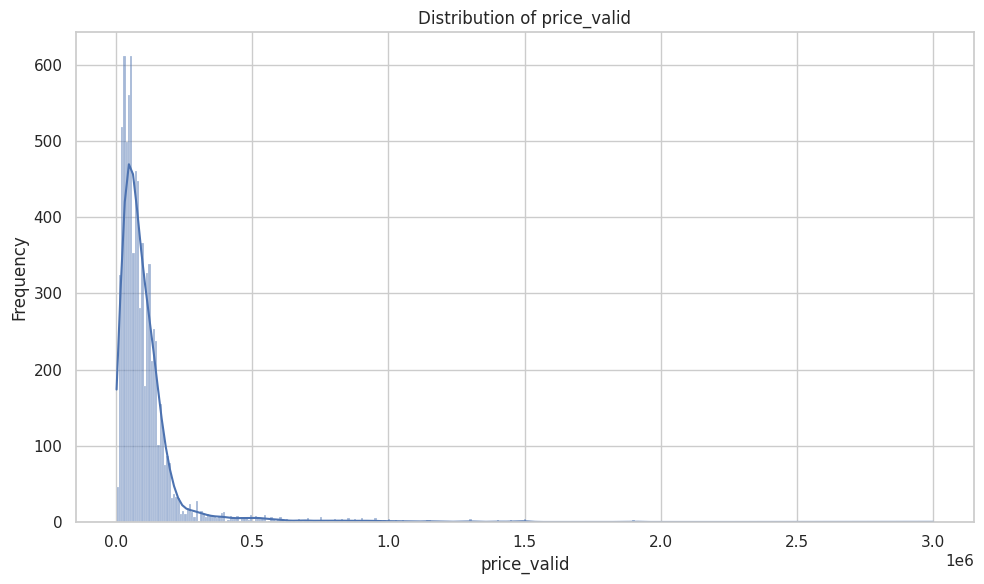

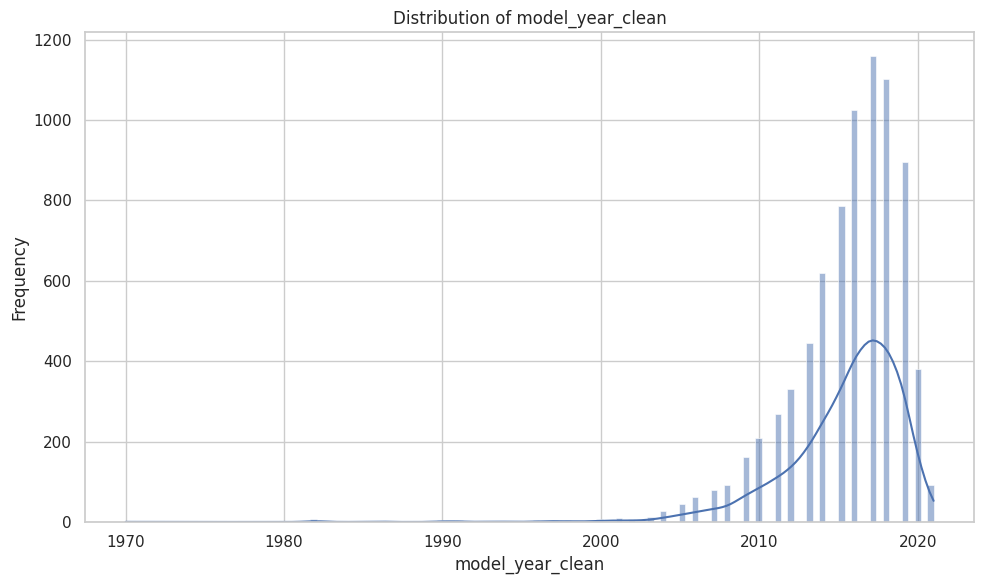

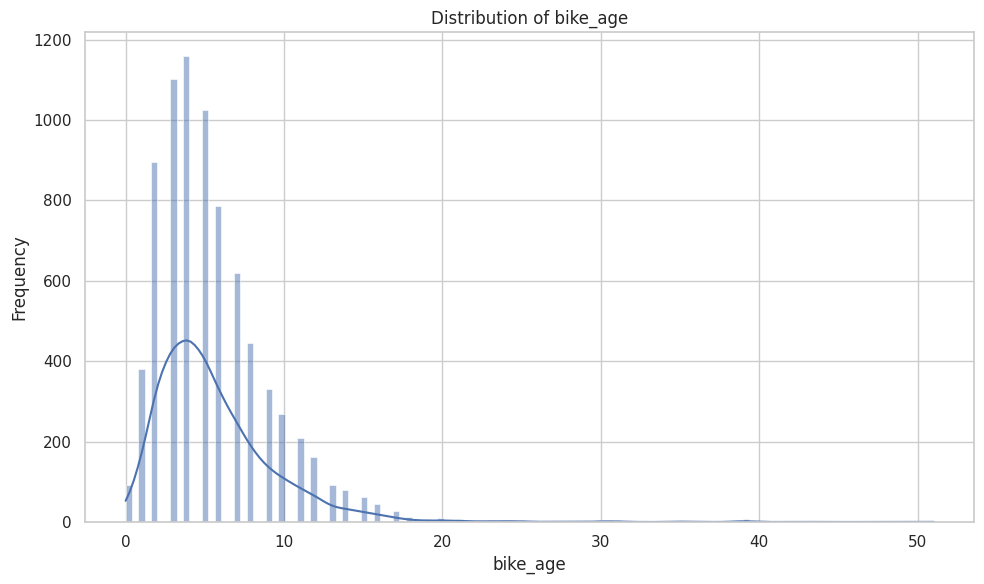

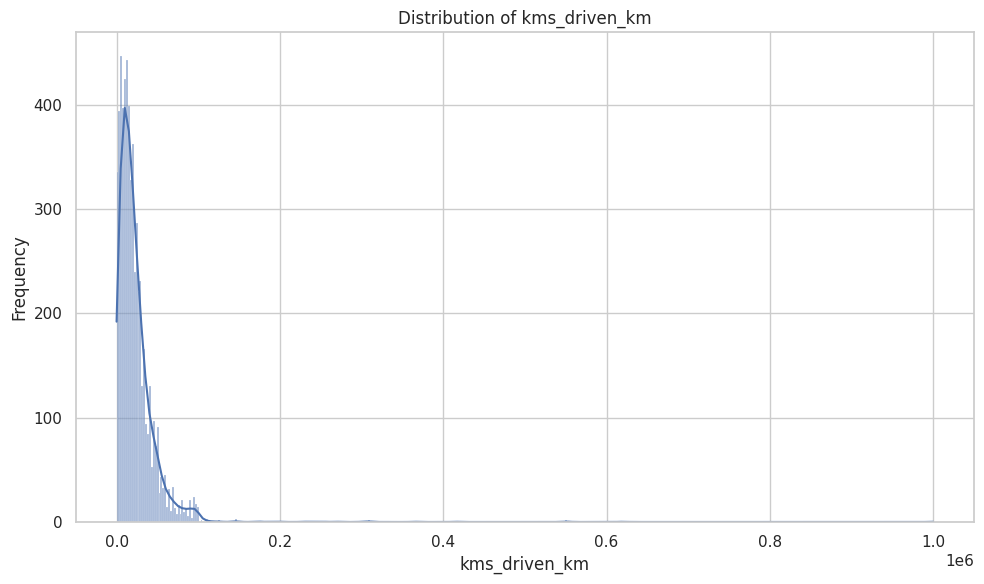

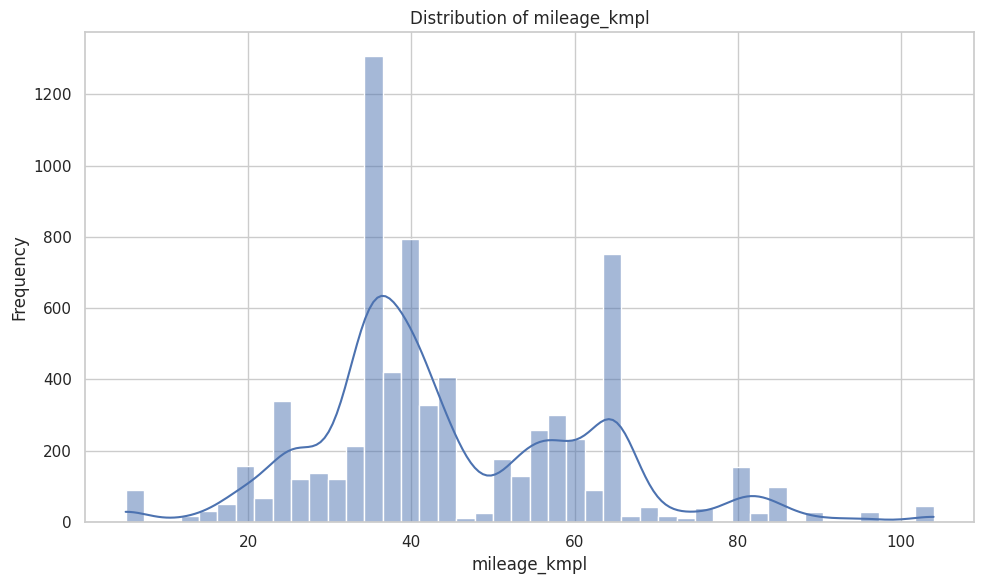

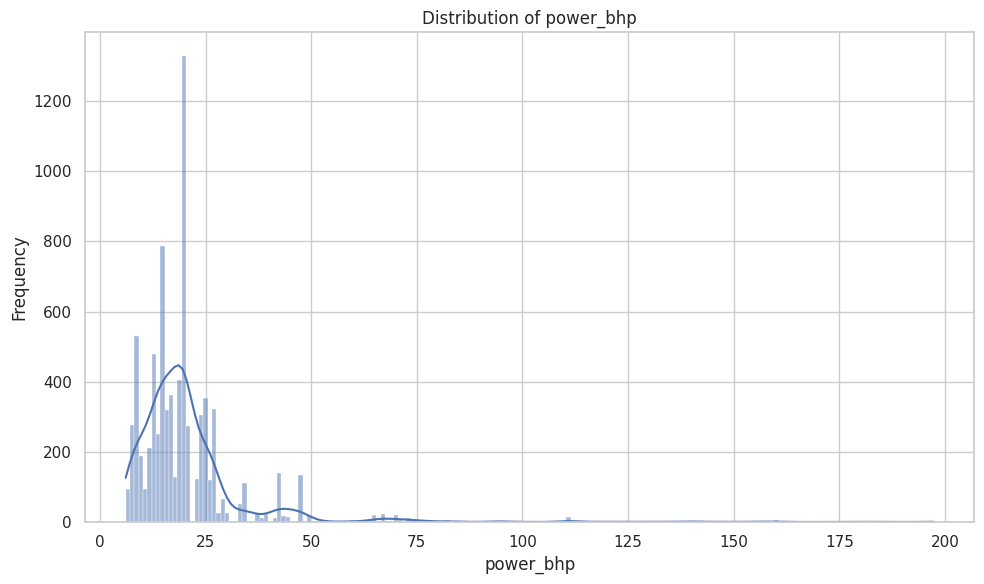

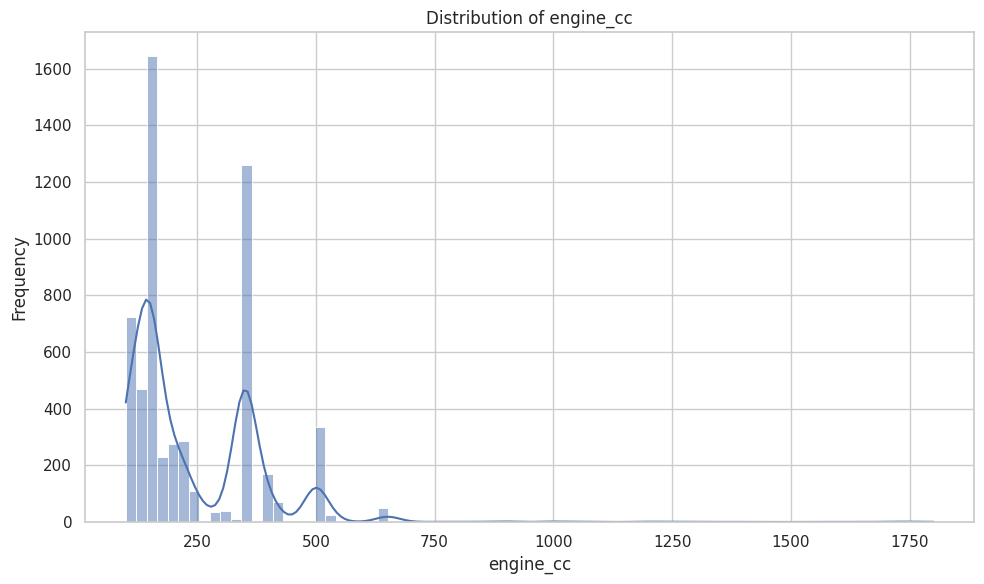

In [12]:
# Histograms
for col in numeric_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


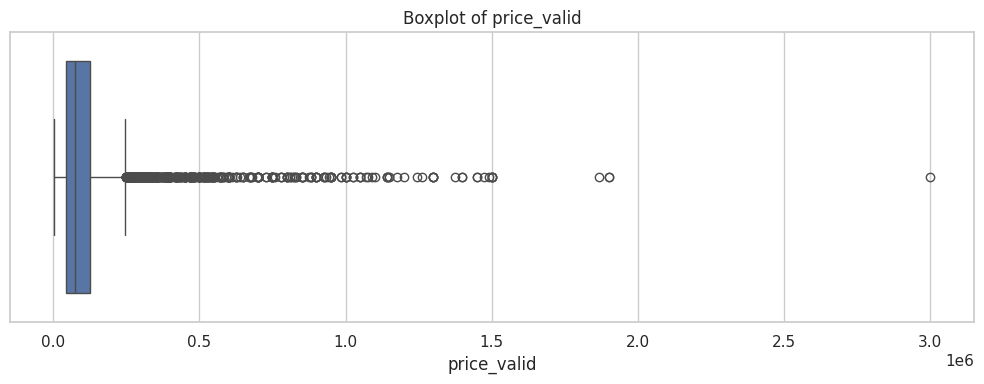

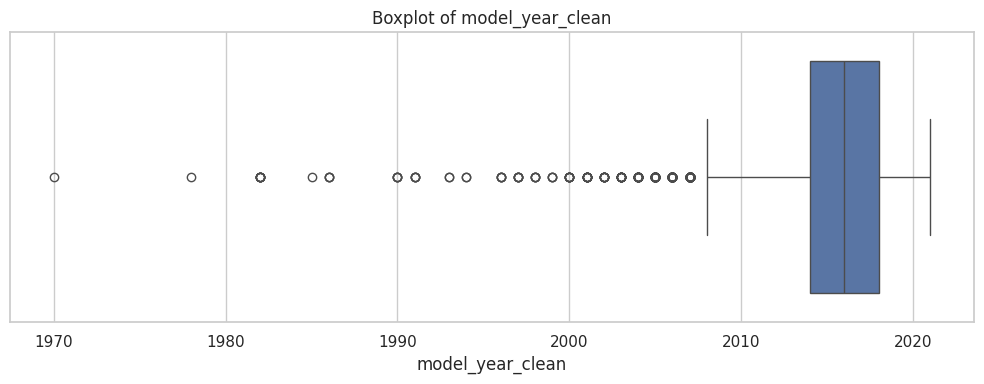

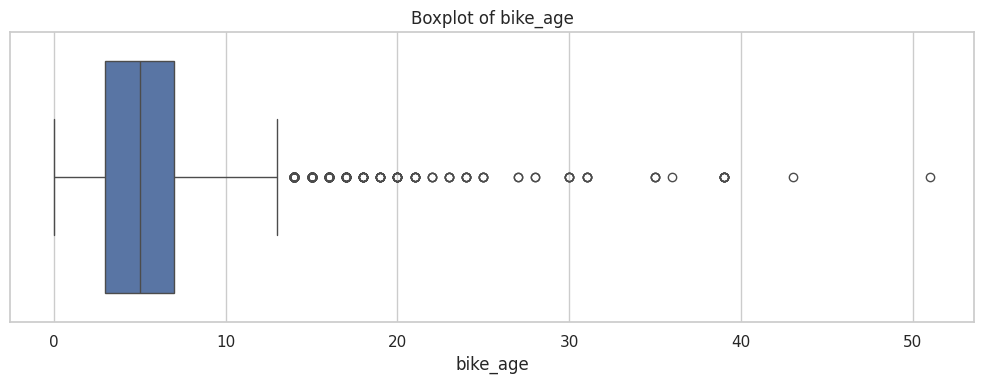

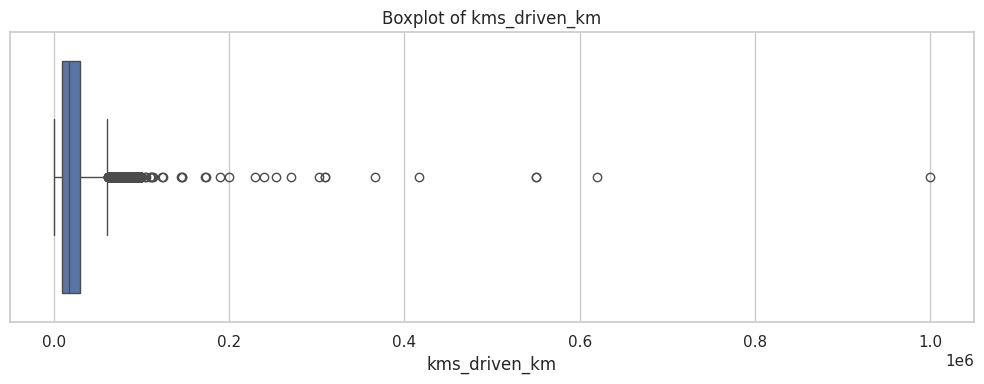

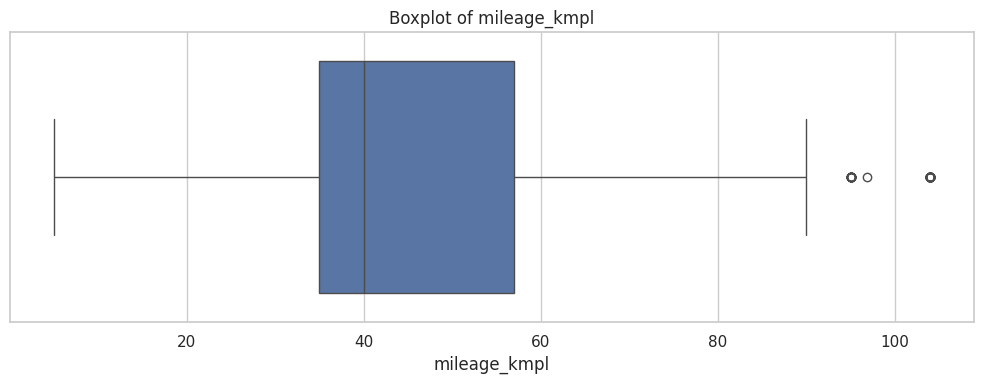

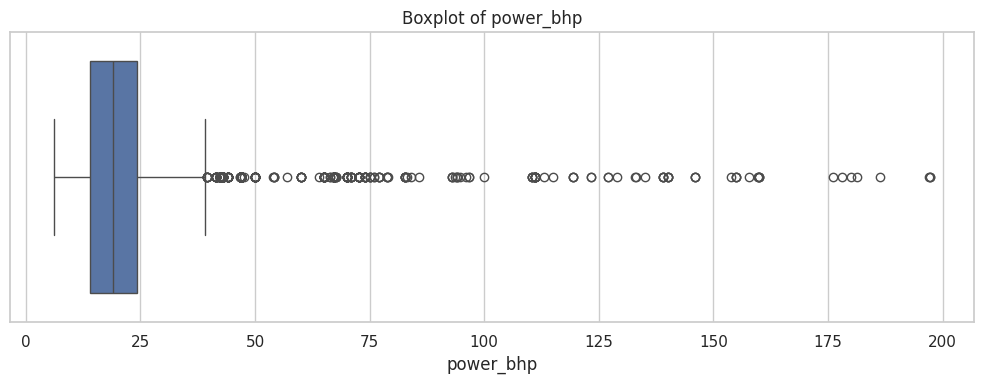

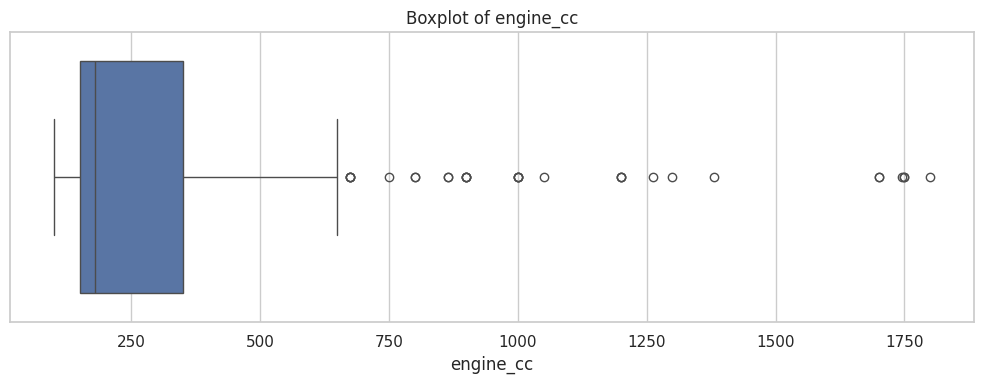

In [13]:
# Boxplots
for col in numeric_cols:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()


In [14]:
categorical_cols = ["owner", "brand", "location_filled"]

for col in categorical_cols:
    freq = df[col].value_counts(dropna=False)
    pct = (freq / len(df) * 100).round(2)
    summary = pd.DataFrame({"count": freq, "percentage": pct})
    print(f"\n--- {col} ---")
    display(summary.head(20))



--- owner ---


,count,percentage
owner,,
first owner,6817,86.76
second owner,833,10.60
third owner,134,1.71
fourth owner or more,73,0.93



--- brand ---


,count,percentage
brand,,
Bajaj,2105,26.79
Royal Enfield,1750,22.27
Hero,808,10.28
Yamaha,748,9.52
TVS,567,7.22
Honda,530,6.75
KTM,491,6.25
Suzuki,223,2.84
Harley-Davidson,171,2.18



--- location_filled ---


,count,percentage
location_filled,,
delhi,1438,18.30
mumbai,857,10.91
bangalore,783,9.97
pune,343,4.37
hyderabad,337,4.29
chennai,322,4.10
gurgaon,311,3.96
jaipur,291,3.70
ahmedabad,235,2.99


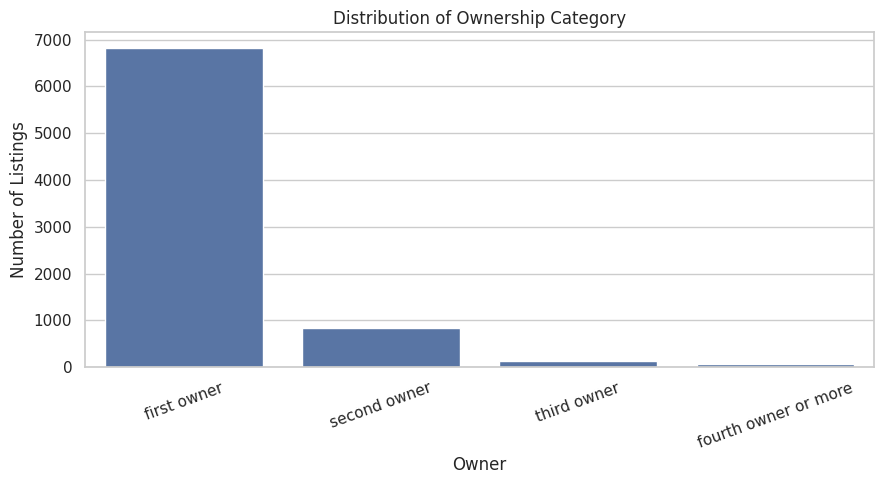

In [15]:
# Owner distribution
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x="owner", order=df["owner"].value_counts().index)
plt.title("Distribution of Ownership Category")
plt.xlabel("Owner")
plt.ylabel("Number of Listings")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 11. Bivariate Analysis — Price Drivers

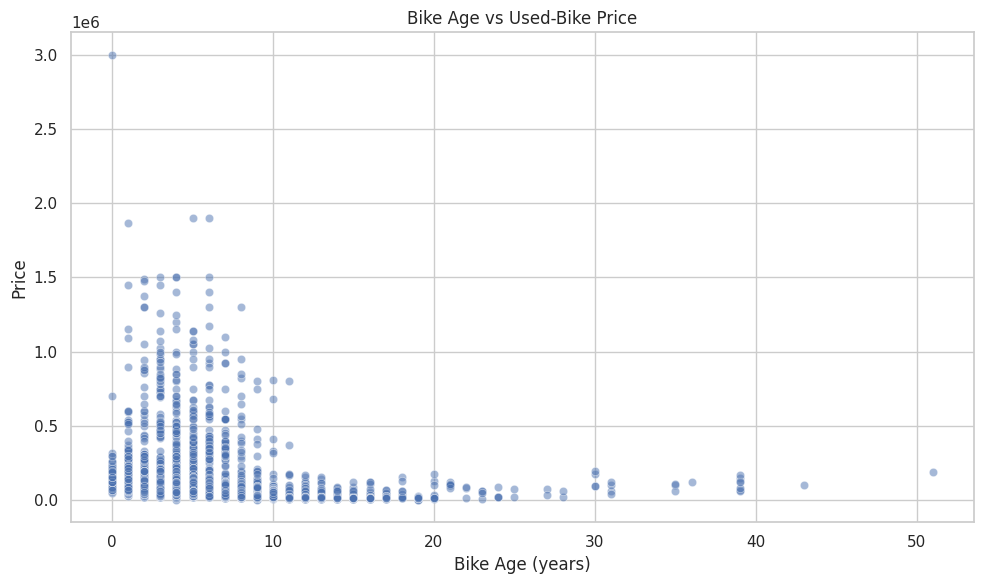

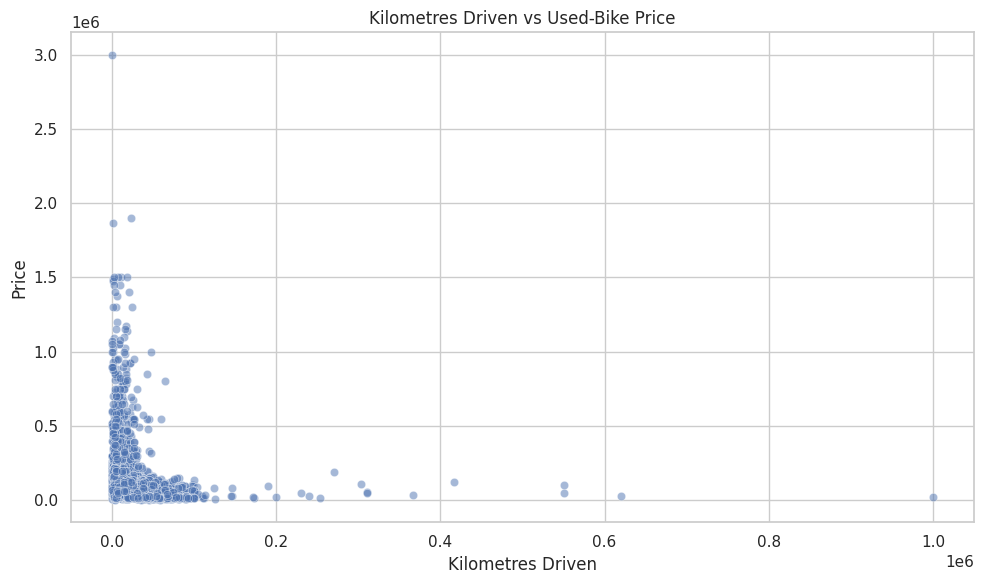

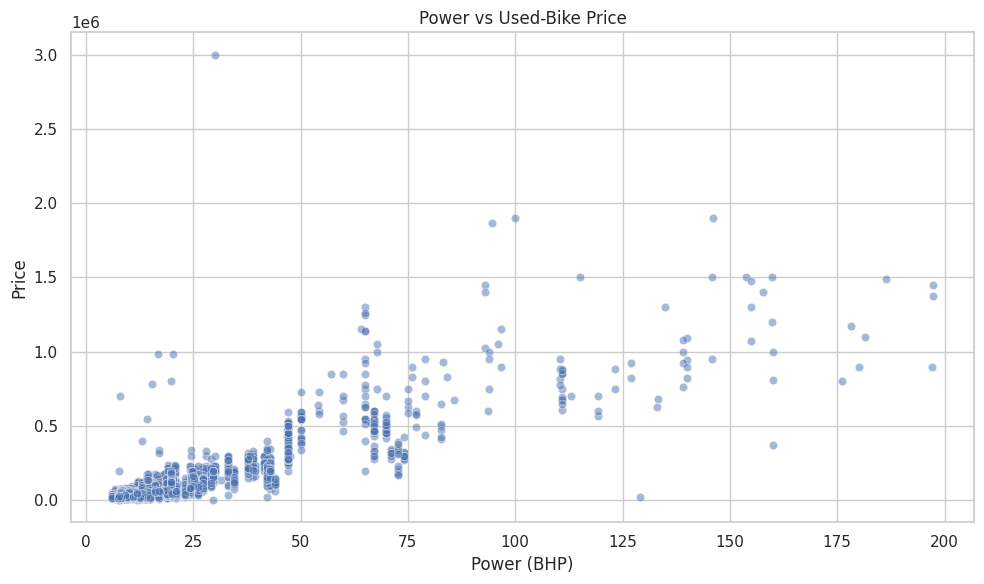

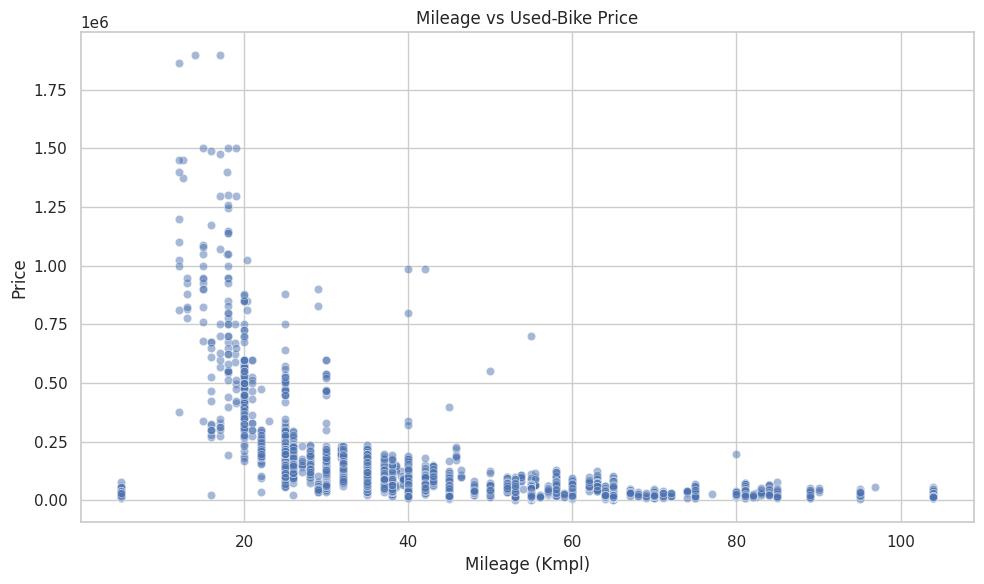

In [16]:
# Price vs age
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="bike_age",
    y="price_valid",
    alpha=0.5
)
plt.title("Bike Age vs Used-Bike Price")
plt.xlabel("Bike Age (years)")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

# Price vs KMS
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="kms_driven_km",
    y="price_valid",
    alpha=0.5
)
plt.title("Kilometres Driven vs Used-Bike Price")
plt.xlabel("Kilometres Driven")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

# Price vs power
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="power_bhp",
    y="price_valid",
    alpha=0.5
)
plt.title("Power vs Used-Bike Price")
plt.xlabel("Power (BHP)")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

# Price vs mileage
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="mileage_kmpl",
    y="price_valid",
    alpha=0.5
)
plt.title("Mileage vs Used-Bike Price")
plt.xlabel("Mileage (Kmpl)")
plt.ylabel("Price")
plt.tight_layout()
plt.show()


### Price by categorical segments

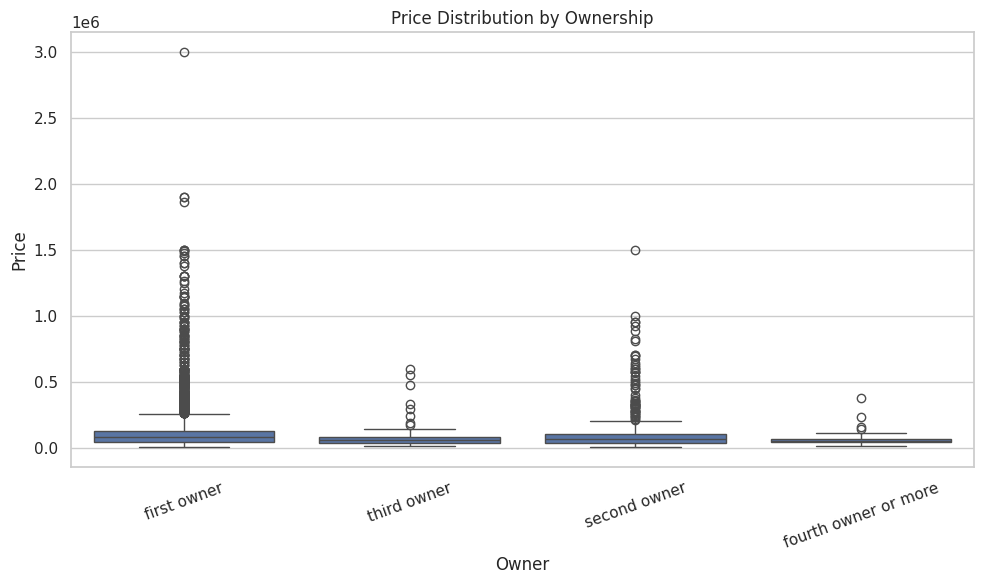

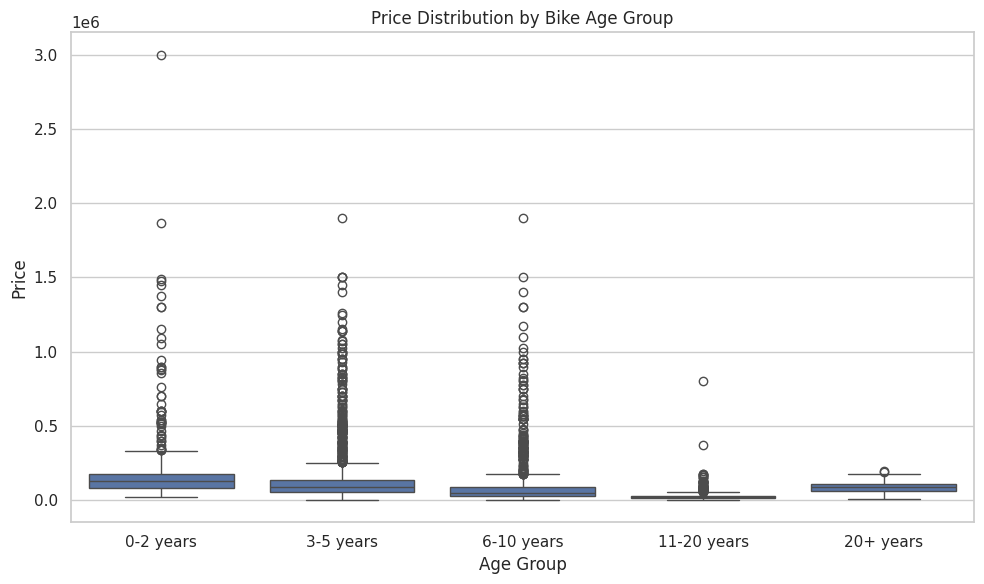

,count,mean,median
brand,,,
Triumph,36,843183.250000,800000.0
Kawasaki,67,496517.701493,465000.0
Harley-Davidson,171,512722.602339,450000.0
Benelli,59,292971.220339,255000.0
Hyosung,52,221660.192308,198600.0
Jawa,46,171286.130435,165000.0
KTM,491,150354.556008,147000.0
UM,128,128446.007812,125000.0
Royal Enfield,1749,125963.046312,120000.0


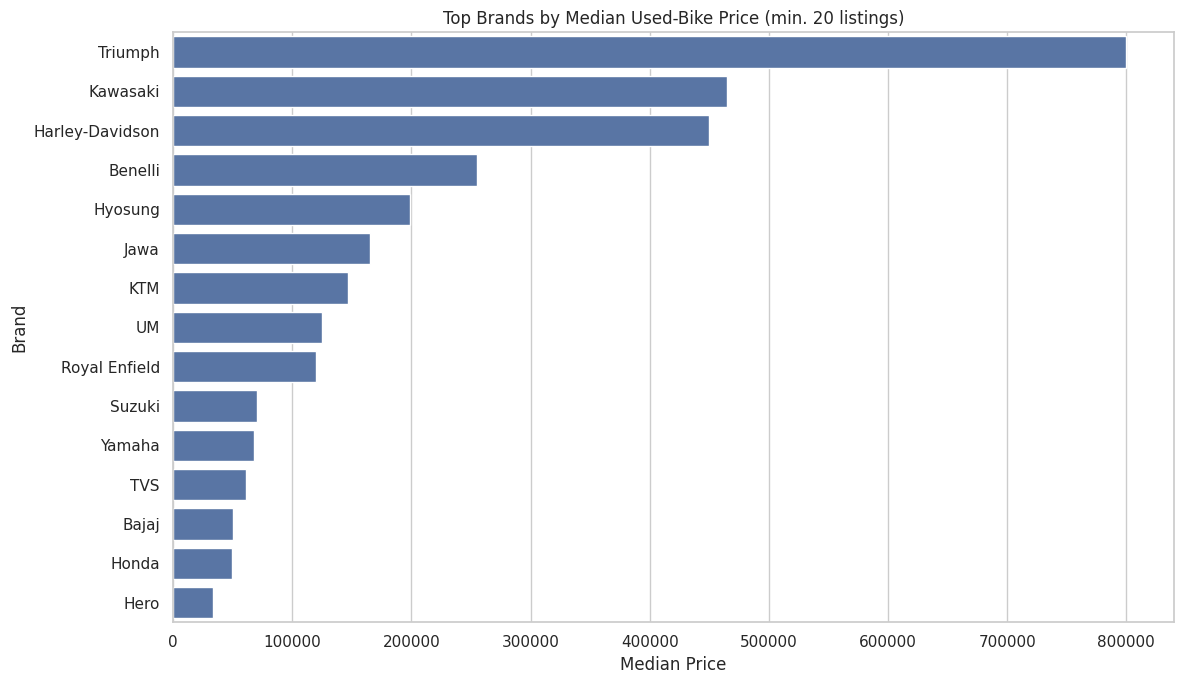

In [17]:
# Price by owner
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="owner", y="price_valid")
plt.title("Price Distribution by Ownership")
plt.xlabel("Owner")
plt.ylabel("Price")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# Price by age group
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="age_group", y="price_valid")
plt.title("Price Distribution by Bike Age Group")
plt.xlabel("Age Group")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

# Top brands by median price, requiring >=20 listings
brand_summary = (
    df.groupby("brand")["price_valid"]
      .agg(["count", "mean", "median"])
      .query("count >= 20")
      .sort_values("median", ascending=False)
)

display(brand_summary.head(15))

plt.figure(figsize=(12, 7))
sns.barplot(
    data=brand_summary.head(15).reset_index(),
    x="median",
    y="brand"
)
plt.title("Top Brands by Median Used-Bike Price (min. 20 listings)")
plt.xlabel("Median Price")
plt.ylabel("Brand")
plt.tight_layout()
plt.show()


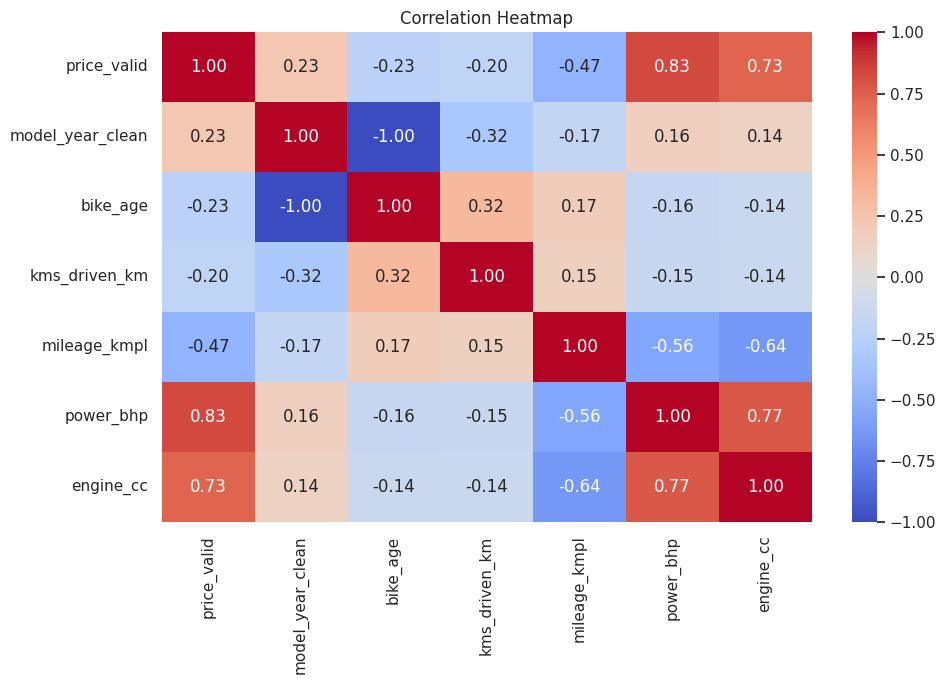

,price_valid
price_valid,1.000000
power_bhp,0.832344
engine_cc,0.733489
model_year_clean,0.231771
kms_driven_km,-0.198557
bike_age,-0.231771
mileage_kmpl,-0.470970


In [18]:
corr_cols = [
    "price_valid", "model_year_clean", "bike_age",
    "kms_driven_km", "mileage_kmpl", "power_bhp", "engine_cc"
]

corr = df[corr_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

display(corr["price_valid"].sort_values(ascending=False))


In [19]:
# Price by age group and owner
pivot_age_owner = pd.pivot_table(
    df,
    values="price_valid",
    index="age_group",
    columns="owner",
    aggfunc="median"
)
display(pivot_age_owner)

# Price by brand and owner for common brands
common_brands = df["brand"].value_counts().head(10).index
pivot_brand_owner = pd.pivot_table(
    df[df["brand"].isin(common_brands)],
    values="price_valid",
    index="brand",
    columns="owner",
    aggfunc="median"
)
display(pivot_brand_owner)


/tmp/ipykernel_428/2084887334.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_age_owner = pd.pivot_table(


owner,first owner,fourth owner or more,second owner,third owner
age_group,,,,
0-2 years,131000.0,55000.0,73000.0,62050.0
3-5 years,90000.0,54000.0,85350.0,56300.0
6-10 years,49000.0,46520.0,50000.0,55000.0
11-20 years,20000.0,23000.0,24875.0,29000.0
20+ years,67500.0,36508.0,86000.0,107500.0


owner,first owner,fourth owner or more,second owner,third owner
brand,,,,
Bajaj,50900.0,47120.0,45000.0,46000.0
Harley-Davidson,450000.0,NaN,388150.0,312500.0
Hero,35000.0,23000.0,25000.0,22500.0
Honda,50000.0,37000.0,49000.0,49900.0
KTM,150000.0,81000.0,125000.0,98000.0
Royal Enfield,124375.0,116750.0,100000.0,94500.0
Suzuki,70450.0,375000.0,60000.0,259000.0
TVS,65000.0,50000.0,58950.0,53000.0
UM,125000.0,NaN,110650.0,95000.0


In [20]:
def iqr_outlier_summary(data, columns):
    rows = []
    for col in columns:
        s = data[col].dropna()
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        outliers = ((s < lower) | (s > upper)).sum()
        rows.append({
            "feature": col,
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "Lower_Bound": lower,
            "Upper_Bound": upper,
            "Outlier_Count": outliers,
            "Outlier_Percentage": round(outliers / len(s) * 100, 2)
        })
    return pd.DataFrame(rows)

outlier_cols = [
    "price_valid", "bike_age", "kms_driven_km",
    "mileage_kmpl", "power_bhp", "engine_cc"
]

outlier_table = iqr_outlier_summary(df, outlier_cols)
display(outlier_table)


,feature,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
0,price_valid,42500.0,125000.00,82500.00,-81250.00,248750.0,438,5.60
1,bike_age,3.0,7.00,4.00,-3.00,13.0,291,3.70
2,kms_driven_km,8903.0,30000.00,21097.00,-22742.50,61645.5,290,4.94
3,mileage_kmpl,35.0,57.00,22.00,2.00,90.0,73,1.03
4,power_bhp,14.0,24.16,10.16,-1.24,39.4,544,6.95
5,engine_cc,150.0,350.00,200.00,-150.00,650.0,30,0.52


In [21]:
price_stats = df["price_valid"].describe()
print("Average price:", round(df["price_valid"].mean(), 2))
print("Median price:", round(df["price_valid"].median(), 2))
print("Minimum valid price:", df["price_valid"].min())
print("Maximum price:", df["price_valid"].max())

print("\nTop 10 most expensive bikes:")
display(
    df.nlargest(10, "price_valid")[
        ["model_name", "model_year_clean", "owner", "location", "price_valid"]
    ]
)

print("\nTop 10 cheapest valid bikes:")
display(
    df.nsmallest(10, "price_valid")[
        ["model_name", "model_year_clean", "owner", "location", "price_valid"]
    ]
)


Average price: 107214.35
Median price: 75000.0
Minimum valid price: 2000.0
Maximum price: 3000000.0

Top 10 most expensive bikes:


,model_name,model_year_clean,owner,location,price_valid
2133,Honda CB300R 2021,2021,first owner,bangalore,3000000.0
4757,Indian Chief Classic 1800cc 2015,2015,first owner,chennai,1900000.0
6778,Triumph Rocket III Roadster 2016,2016,first owner,pune,1900000.0
3252,Moto Guzzi Audace 1380cc 2020,2020,first owner,pune,1866057.0
5067,Harley-Davidson Night Rod Special 2015,2015,second owner,mumbai,1500000.0
5401,Ducati XDiavel 1262CC S 2017,2017,first owner,alibag,1500000.0
5586,BMW S 1000 XR Pro 2017,2017,first owner,delhi,1500000.0
5951,MV Agusta F3 800cc 2018,2018,first owner,hubli,1500000.0
2257,Honda CBR1000RR Fireblade SP 2019,2019,first owner,delhi,1490000.0
5487,Ducati Panigale 959 2019,2019,first owner,delhi,1475000.0



Top 10 cheapest valid bikes:


,model_name,model_year_clean,owner,location,price_valid
6954,Hero CD Deluxe 100cc 2012,2012,first owner,dwarka,2000.0
1252,Suzuki Fiero 150cc 2002,2002,first owner,chennai,3900.0
1680,Hero Passion 100cc 2002,2002,second owner,raipur,3900.0
5739,KTM Duke 250cc 2017,2017,first owner,delhi,5000.0
1247,Hero Glamour 125cc 2006,2006,first owner,delhi,5850.0
427,Bajaj 4S champion 100cc 1998,1998,first owner,indore,6000.0
7306,yamaha Libero 110cc 2006,2006,first owner,ghaziabad,6000.0
4530,Honda CB Unicorn 150cc 2005,2005,first owner,delhi,7000.0
3359,Bajaj Pulsar 135LS 2012,2012,first owner,gurgaon,7500.0
3494,Bajaj Discover 125cc 2005,2005,first owner,delhi,7500.0


In [22]:
# Price by age group
age_price = (
    df.groupby("age_group", observed=True)["price_valid"]
      .agg(["count", "mean", "median"])
)
display(age_price)

# Price by mileage group
kms_price = (
    df.groupby("kms_group", observed=True)["price_valid"]
      .agg(["count", "mean", "median"])
)
display(kms_price)

# Brand summary
brand_price = (
    df.groupby("brand")["price_valid"]
      .agg(["count", "mean", "median"])
      .query("count >= 20")
      .sort_values("mean", ascending=False)
)
display(brand_price.head(15))

# Location summary, require at least 30 listings
location_price = (
    df.groupby("location_filled")["price_valid"]
      .agg(["count", "mean", "median"])
      .query("count >= 30")
      .sort_values("mean", ascending=False)
)
display(location_price.head(15))


,count,mean,median
age_group,,,
0-2 years,1366,153374.420205,128000.0
3-5 years,3287,121901.871311,90000.0
6-10 years,2436,83323.857964,49969.5
11-20 years,692,31739.773121,20000.0
20+ years,45,87061.866667,90000.0


,count,mean,median
kms_group,,,
<5k,832,206095.335337,150000.0
5k-15k,1812,145426.091611,119000.0
15k-30k,1836,100576.242375,75000.0
30k-60k,1070,60869.858879,46500.0
60k+,293,49789.945392,47000.0


,count,mean,median
brand,,,
Triumph,36,843183.250000,800000.0
Harley-Davidson,171,512722.602339,450000.0
Kawasaki,67,496517.701493,465000.0
Benelli,59,292971.220339,255000.0
Hyosung,52,221660.192308,198600.0
Jawa,46,171286.130435,165000.0
KTM,491,150354.556008,147000.0
UM,128,128446.007812,125000.0
Royal Enfield,1749,125963.046312,120000.0


,count,mean,median
location_filled,,,
mumbai,857,164682.672112,118800.0
jalandhar,40,151049.975000,114500.0
chandigarh,158,131793.424051,135000.0
rajkot,43,126313.790698,122883.0
pune,343,120407.061224,80000.0
indore,42,120355.904762,87300.0
bangalore,782,116769.744246,80000.0
thane,94,111342.893617,88093.5
hyderabad,336,107041.470238,85000.0


In [23]:
value_counts = df["value_segment"].value_counts()
display(value_counts)

print("Potentially underpriced examples:")
display(
    df[df["value_segment"] == "potentially_underpriced"]
    .sort_values("model_price_index")
    [["model_name", "price_valid", "model_price_index"]]
    .head(15)
)

print("Potentially overpriced examples:")
display(
    df[df["value_segment"] == "potentially_overpriced"]
    .sort_values("model_price_index", ascending=False)
    [["model_name", "price_valid", "model_price_index"]]
    .head(15)
)


,count
value_segment,
within_model_range,6692
potentially_overpriced,642
potentially_underpriced,523


Potentially underpriced examples:


,model_name,price_valid,model_price_index
5739,KTM Duke 250cc 2017,5000.0,0.033784
6954,Hero CD Deluxe 100cc 2012,2000.0,0.088889
5447,KTM RC 390cc 2017,23000.0,0.125455
6353,Honda CB Unicorn 150cc 2010,10000.0,0.332851
3359,Bajaj Pulsar 135LS 2012,7500.0,0.340909
733,Royal Enfield Classic 350cc 2016,41250.0,0.343750
1036,Royal Enfield Classic 350cc 2016,41250.0,0.343750
2658,Yamaha YZF-R15 V3 150cc Darknight edition BS6 ...,52500.0,0.350000
4530,Honda CB Unicorn 150cc 2005,7000.0,0.358974
6987,Honda CB Unicorn 150cc 2013,20200.0,0.367273


Potentially overpriced examples:


,model_name,price_valid,model_price_index
5640,Yamaha YZF-R15 2.0 150cc 2017,985625.0,11.622936
6622,Yamaha Fazer 150cc 2014,400000.0,11.428571
4145,Bajaj Pulsar NS160 2018,780000.0,11.386861
5678,TVS Apache RTR 200 4V ABS 2018,985625.0,11.200284
393,Bajaj Avenger Street 150 2016,550000.0,10.556622
3943,Royal Enfield Bullet Electra 350cc 2012,800000.0,10.204082
4628,Hero Karizma R 223cc 2011,320000.0,9.142857
5895,Bajaj Pulsar 150cc 2006,42000.0,3.818182
2502,Bajaj Pulsar 220cc 2011,80000.0,2.962963
447,Bajaj Pulsar 150cc 2009,45000.0,2.884615


,count,mean,median
model_year_clean,,,
1970,1,190000.000000,190000.0
1978,1,100000.000000,100000.0
1982,7,112142.857143,125000.0
1985,1,125000.000000,125000.0
1986,3,90000.000000,100000.0
1990,4,82187.500000,81875.0
1991,4,142000.000000,136500.0
1993,2,42500.000000,42500.0
1994,2,57254.000000,57254.0


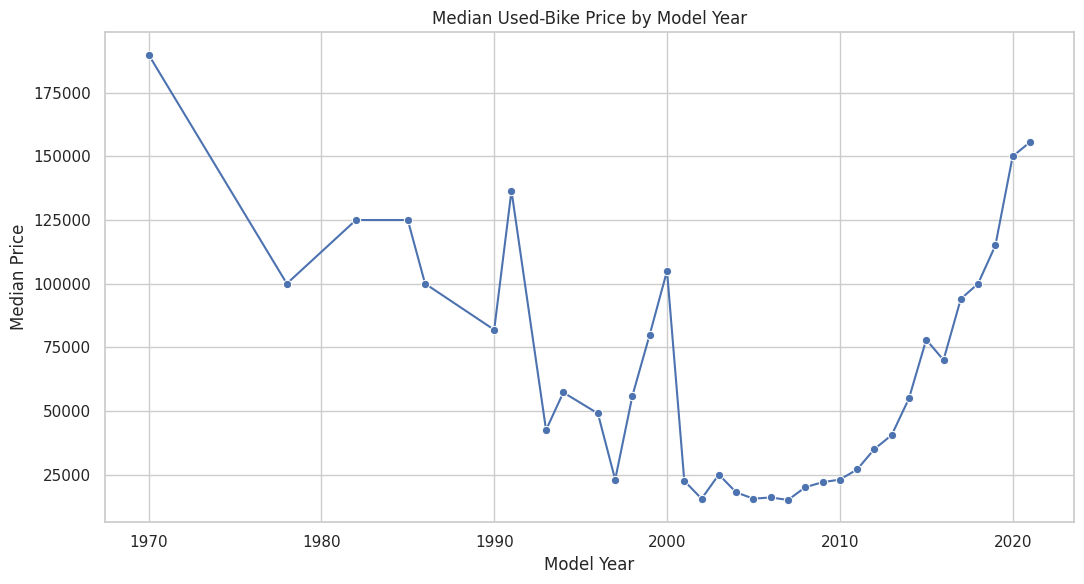

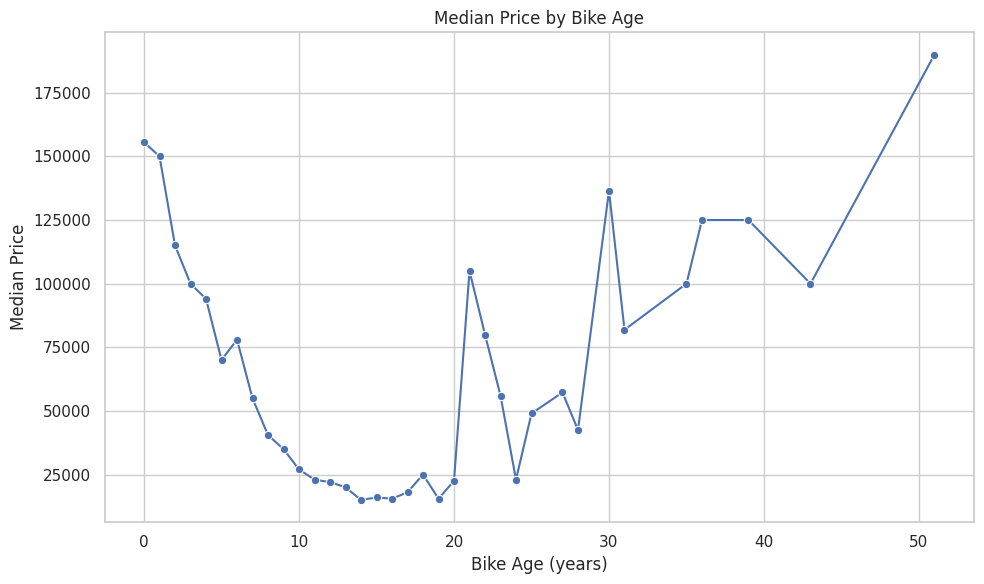

In [24]:
# Median price by model year
year_price = (
    df.groupby("model_year_clean")["price_valid"]
      .agg(["count", "mean", "median"])
      .sort_index()
)

display(year_price)

plt.figure(figsize=(11, 6))
sns.lineplot(
    data=year_price.reset_index(),
    x="model_year_clean",
    y="median",
    marker="o"
)
plt.title("Median Used-Bike Price by Model Year")
plt.xlabel("Model Year")
plt.ylabel("Median Price")
plt.tight_layout()
plt.show()

# Age vs median price
age_median = df.groupby("bike_age")["price_valid"].median().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=age_median, x="bike_age", y="price_valid", marker="o")
plt.title("Median Price by Bike Age")
plt.xlabel("Bike Age (years)")
plt.ylabel("Median Price")
plt.tight_layout()
plt.show()


## 18. Key Findings — Dataset-Supported

Based on the cleaned dataset, the main findings are:

1. The dataset contains **7,857 listings** across **1,724 distinct model names**.
2. Price is highly dispersed: the valid-price mean is about **₹107k**, while the median is about **₹75k**, showing right skew.
3. `power_bhp` has a strong positive correlation with price (**~0.83**).
4. Extracted `engine_cc` also has a strong positive correlation with price (**~0.73**), although it is available for only part of the dataset.
5. Bike age has a negative relationship with price (**~−0.23** correlation).
6. Kilometres driven has a negative relationship with price (**~−0.20** correlation) among observations with valid KMS.
7. Mileage has a moderate negative correlation with price (**~−0.47**); this should be interpreted cautiously because mileage also reflects bike segment.
8. First-owner bikes have the highest observed mean price among ownership categories.
9. Premium brands such as Triumph, Harley-Davidson, and Kawasaki have much higher average prices than mass-market brands, subject to their smaller sample sizes.
10. The most common brands in the dataset are Bajaj and Royal Enfield, making them useful for robust segment comparisons.
11. Lower-KMS groups have substantially higher median prices than high-KMS groups.
12. Newer age groups command materially higher median prices than older groups.
13. The dataset contains malformed KMS records where mileage-like text appears in the KMS field; these should not be numerically interpreted.
14. There are zero-price records that are invalid for financial analysis and should be excluded from price calculations.
15. Relative model-level price screening identifies listings that are unusually cheap or expensive compared with other listings of the same model, but these should be treated as leads for further investigation rather than definitive valuation conclusions.


## 19. Business Recommendations

### Buyers
- Compare listings against the same model rather than relying only on overall market averages.
- Prioritize lower usage, newer age, and appropriate power/engine segment.
- Investigate listings whose price is far below the model's typical price; the discount may reflect condition, documentation, or data-quality issues.

### Sellers
- Highlight low usage, newer model year, first ownership, and strong specifications where applicable.
- Benchmark the asking price against comparable listings of the same model.
- Premium brands can support higher asking prices, but the premium should still be justified by condition and usage.

### Used-bike Dealers
- Segment inventory by brand, age, usage, power, and engine capacity.
- Monitor unusually low-priced listings as potential acquisition opportunities, subject to physical inspection and documentation.
- Avoid using simple average price as the only valuation metric because the market is highly heterogeneous.

### Online Marketplaces
- Build model-level price benchmarks.
- Flag suspiciously low or high listings for review.
- Provide filters for age, kilometres driven, ownership, engine capacity, and power.
- Use robust pricing models rather than raw averages to generate estimated market values.


## 20. Data Cleaning Summary

| Issue | Detection | Treatment | Reason |
|---|---|---|---|
| Missing location | `isna()` | Preserve / optional `Unknown` | Categorical and low missingness |
| Missing mileage | blank/NaN check | Preserve as missing | Avoid unsupported imputation during EDA |
| Missing power | `isna()` | Preserve as missing | Avoid unsupported imputation during EDA |
| Malformed KMS | values containing `Mileage` or `Yes Km` | Convert to missing | Prevent false kilometre values |
| Text numeric fields | dtype inspection | Extract numeric component | Required for quantitative analysis |
| Zero prices | `price <= 0` | Exclude from price analysis | Not credible sale prices |
| Duplicate rows | `duplicated()` | No removal required | No full duplicates found |
| Year anomaly | model year 1950 vs model-name year 2013 | Correct obvious isolated inconsistency | Strong internal evidence |


## 21. Final Conclusion

The used-bike market in this dataset is strongly segmented. Price is associated most strongly with performance-related characteristics such as power and engine capacity, while age and usage tend to be negatively associated with price. Brand and ownership also separate market segments.

The most important analytical lesson is that **data quality comes before interpretation**: the raw dataset contains text-formatted numeric variables, malformed KMS entries, missing values, and invalid zero prices. Cleaning these issues carefully makes the subsequent EDA substantially more reliable.

The project demonstrates a complete professional workflow: data audit → cleaning → EDA → outlier analysis → feature engineering → price segmentation → business interpretation.


In [25]:
print("Final shape:", df.shape)
print("\nFinal columns:")
print(df.columns.tolist())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nValid price records:", df["price_valid"].notna().sum())

print("\nClean numerical dtypes:")
display(df[
    ["model_year_clean", "kms_driven_km", "mileage_kmpl",
     "power_bhp", "price_valid", "bike_age", "engine_cc"]
].dtypes)


Final shape: (7857, 25)

Final columns:
['model_name', 'model_year', 'kms_driven', 'owner', 'location', 'mileage', 'power', 'price', 'kms_driven_km', 'mileage_kmpl', 'power_bhp', 'year_in_name', 'model_year_clean', 'price_valid', 'location_filled', 'bike_age', 'engine_cc', 'age_group', 'kms_group', 'brand', 'price_per_bhp', 'price_per_cc', 'kms_per_year', 'model_price_index', 'value_segment']

Duplicate rows: 0

Valid price records: 7826

Clean numerical dtypes:


,0
model_year_clean,int64
kms_driven_km,float64
mileage_kmpl,float64
power_bhp,float64
price_valid,float64
bike_age,int64
engine_cc,float64
